# Tahap 11 — Model Improvement dan Perbandingan Model Klasifikasi Sentimen

Notebook ini merupakan lanjutan dari tahap baseline modeling pada project:

**Analisis Sentimen Komentar YouTube terhadap Isu Pelemahan Nilai Rupiah dan Dampaknya terhadap Persepsi Daya Beli Masyarakat Menggunakan Python, Jupyter Notebook, GitHub, dan Streamlit.**

Pada tahap sebelumnya, model baseline menggunakan kombinasi **TF-IDF + Multinomial Naive Bayes**. Model tersebut sudah berhasil dijalankan, tetapi hasil evaluasi menunjukkan bahwa model masih terlalu dominan memprediksi kelas `netral`, sehingga recall untuk kelas `negatif` dan `positif` masih rendah.

Oleh karena itu, tahap ini difokuskan pada **model improvement** dengan tetap menggunakan pendekatan machine learning klasik yang relevan untuk klasifikasi teks.

## 1. Tujuan Tahap

Tujuan dari tahap ini adalah:

1. Melakukan peningkatan performa model klasifikasi sentimen dibandingkan baseline Naive Bayes.
2. Menguji model pembanding yang relevan untuk klasifikasi teks, yaitu:
   - Logistic Regression dengan `class_weight="balanced"`
   - Linear Support Vector Machine atau LinearSVC
3. Menjaga agar proses perbandingan model tetap adil dengan menggunakan feature extraction yang sama, yaitu **TF-IDF**.
4. Mengevaluasi model menggunakan metrik:
   - Accuracy
   - Precision Macro
   - Recall Macro
   - F1-Score Macro
   - Precision Weighted
   - Recall Weighted
   - F1-Score Weighted
   - Classification Report
   - Confusion Matrix
5. Menganalisis apakah model improvement mampu memperbaiki recall dan F1-score pada kelas `negatif` dan `positif`.
6. Menyimpan laporan evaluasi dan visualisasi agregat secara aman ke folder `reports/`.

## 2. Output yang Dihasilkan

Output yang akan dihasilkan dari tahap ini adalah:

1. Notebook model improvement:
   - `notebooks/11_model_improvement_sentiment_classification.ipynb`

2. Laporan evaluasi model dalam folder:
   - `reports/`

3. Visualisasi agregat yang aman, seperti:
   - Perbandingan metrik antar model
   - Confusion matrix per model

4. Ringkasan perbandingan model:
   - Baseline Naive Bayes
   - Logistic Regression Balanced
   - LinearSVC

5. Checklist keamanan sebelum file dipush ke GitHub.

Catatan keamanan:

- Dataset komentar tidak akan disimpan ulang ke GitHub.
- File `.env` tidak akan dibaca atau ditampilkan.
- API key tidak akan ditampilkan.
- Kolom `author` tidak akan ditampilkan.
- Sampel komentar, jika diperlukan, hanya akan ditampilkan secara terbatas dan dipotong panjang teksnya.
- Model artifact yang berisi vocabulary atau fitur teks tidak akan dipublikasikan ke GitHub.

## 3. Konsep Model Improvement

Model baseline pada tahap sebelumnya menggunakan **TF-IDF + Multinomial Naive Bayes**. Hasil evaluasi menunjukkan bahwa model memiliki accuracy yang cukup, tetapi belum seimbang dalam mengenali seluruh kelas sentimen. Model cenderung memprediksi mayoritas data sebagai kelas `netral`.

Permasalahan utama pada baseline adalah:

1. Recall kelas `negatif` masih rendah.
2. Recall kelas `positif` masih rendah.
3. Model terlalu dominan memprediksi kelas `netral`.
4. F1-score macro masih rendah karena performa antar kelas tidak seimbang.

Pada tahap ini, dilakukan model improvement dengan dua pendekatan:

### 3.1 Logistic Regression dengan Class Weight Balanced

Logistic Regression sering digunakan dalam klasifikasi teks karena bekerja baik pada data sparse hasil TF-IDF. Penggunaan `class_weight="balanced"` bertujuan membantu model memperhatikan kelas minoritas dengan memberikan bobot lebih besar pada kelas yang jumlah datanya lebih sedikit.

### 3.2 LinearSVC

Linear Support Vector Machine juga umum digunakan untuk klasifikasi teks karena mampu bekerja efektif pada data berdimensi tinggi seperti representasi TF-IDF. LinearSVC cenderung kuat untuk kasus klasifikasi dokumen atau komentar pendek.

Agar perbandingan tetap adil, semua model akan menggunakan pendekatan feature extraction yang sama, yaitu **TF-IDF**.

In [1]:
# ============================================================
# Tahap 11 - Model Improvement Sentiment Classification
# Bagian 1: Import Library
# ============================================================

import os
import re
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt

# Scikit-learn: preprocessing, splitting, modeling, dan evaluasi
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Mengurangi warning yang tidak kritis agar output notebook lebih bersih
warnings.filterwarnings("ignore")

print("Library berhasil diimport.")

Library berhasil diimport.


In [2]:
# ============================================================
# Konfigurasi Awal
# ============================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Label sentimen yang digunakan dalam project
EXPECTED_LABELS = ["negatif", "netral", "positif"]

# Kolom yang tidak boleh ditampilkan karena berpotensi sensitif
SENSITIVE_COLUMNS = [
    "author",
    "author_name",
    "channel_id",
    "user_id",
    "profile_image_url"
]

print("Konfigurasi awal berhasil dibuat.")
print(f"Random state : {RANDOM_STATE}")
print(f"Test size    : {TEST_SIZE}")
print(f"Expected labels: {EXPECTED_LABELS}")

Konfigurasi awal berhasil dibuat.
Random state : 42
Test size    : 0.2
Expected labels: ['negatif', 'netral', 'positif']


In [3]:
# ============================================================
# Deteksi Project Root
# ============================================================

def find_project_root(start_path=None):
    """
    Fungsi untuk mendeteksi root project secara otomatis.
    
    Root project diasumsikan sebagai folder yang memiliki kombinasi:
    - folder notebooks
    - folder data
    - folder reports
    atau memiliki folder .git
    """
    if start_path is None:
        start_path = Path.cwd()
    else:
        start_path = Path(start_path)

    current_path = start_path.resolve()

    for path in [current_path] + list(current_path.parents):
        has_project_folders = (
            (path / "notebooks").exists() and
            (path / "data").exists()
        )
        has_git = (path / ".git").exists()

        if has_project_folders or has_git:
            return path

    raise FileNotFoundError(
        "Project root tidak ditemukan. "
        "Pastikan notebook dijalankan dari folder project atau subfolder notebooks."
    )


PROJECT_ROOT = find_project_root()

DATA_MODELING_DIR = PROJECT_ROOT / "data" / "modeling"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

# Membuat folder reports dan figures jika belum tersedia
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root berhasil terdeteksi.")
print(f"Project root       : {PROJECT_ROOT}")
print(f"Data modeling dir  : {DATA_MODELING_DIR}")
print(f"Reports dir        : {REPORTS_DIR}")
print(f"Figures dir        : {FIGURES_DIR}")

Project root berhasil terdeteksi.
Project root       : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis
Data modeling dir  : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\modeling
Reports dir        : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports
Figures dir        : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\figures


In [4]:
# ============================================================
# Deteksi Dataset Modeling Terbaru
# ============================================================

def get_latest_modeling_dataset(data_dir):
    """
    Fungsi untuk mengambil file dataset modeling terbaru dari folder data/modeling.
    
    Format file yang didukung:
    - .csv
    - .xlsx
    - .parquet
    
    Dataset dipilih berdasarkan waktu modifikasi terbaru.
    """
    data_dir = Path(data_dir)

    if not data_dir.exists():
        raise FileNotFoundError(
            f"Folder data/modeling tidak ditemukan: {data_dir}"
        )

    supported_patterns = ["*.csv", "*.xlsx", "*.parquet"]
    dataset_files = []

    for pattern in supported_patterns:
        dataset_files.extend(list(data_dir.glob(pattern)))

    if len(dataset_files) == 0:
        raise FileNotFoundError(
            f"Tidak ada file dataset modeling ditemukan di folder: {data_dir}"
        )

    latest_file = max(dataset_files, key=lambda file: file.stat().st_mtime)
    modified_time = datetime.fromtimestamp(latest_file.stat().st_mtime)

    return latest_file, modified_time


latest_dataset_path, latest_modified_time = get_latest_modeling_dataset(DATA_MODELING_DIR)

print("Dataset modeling terbaru berhasil ditemukan.")
print(f"Nama file          : {latest_dataset_path.name}")
print(f"Waktu modifikasi   : {latest_modified_time}")

Dataset modeling terbaru berhasil ditemukan.
Nama file          : youtube_comments_modeling_ready_20260529_171713.csv
Waktu modifikasi   : 2026-05-29 17:17:13.673361


In [5]:
# ============================================================
# Load Dataset Modeling Secara Aman
# ============================================================

def load_dataset_safely(file_path):
    """
    Fungsi untuk membaca dataset modeling berdasarkan ekstensi file.
    Dataset hanya dibaca sebagai input dan tidak disimpan ulang.
    """
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()

    if suffix == ".csv":
        df = pd.read_csv(file_path)
    elif suffix == ".xlsx":
        df = pd.read_excel(file_path)
    elif suffix == ".parquet":
        df = pd.read_parquet(file_path)
    else:
        raise ValueError(
            f"Format file tidak didukung: {suffix}. "
            "Gunakan .csv, .xlsx, atau .parquet."
        )

    return df


df_modeling = load_dataset_safely(latest_dataset_path)

print("Dataset modeling berhasil dibaca secara aman.")
print(f"Jumlah baris : {df_modeling.shape[0]}")
print(f"Jumlah kolom : {df_modeling.shape[1]}")

Dataset modeling berhasil dibaca secara aman.
Jumlah baris : 3661
Jumlah kolom : 2


In [6]:
# ============================================================
# Proteksi Kolom Sensitif
# ============================================================

# Deteksi kolom sensitif yang mungkin terdapat pada dataset
existing_sensitive_columns = [
    col for col in SENSITIVE_COLUMNS if col in df_modeling.columns
]

if existing_sensitive_columns:
    print("Kolom sensitif terdeteksi dan tidak akan digunakan dalam proses modeling:")
    print(existing_sensitive_columns)

    # Kolom sensitif dihapus dari dataframe kerja agar tidak tampil dan tidak digunakan
    df_modeling = df_modeling.drop(columns=existing_sensitive_columns)
else:
    print("Tidak ada kolom sensitif yang terdeteksi.")

print("Proteksi kolom sensitif selesai.")

Tidak ada kolom sensitif yang terdeteksi.
Proteksi kolom sensitif selesai.


In [7]:
# ============================================================
# Menampilkan Struktur Kolom Secara Aman
# ============================================================

safe_columns = [col for col in df_modeling.columns if col not in SENSITIVE_COLUMNS]

print("Daftar kolom yang tersedia untuk proses modeling:")
for idx, col in enumerate(safe_columns, start=1):
    print(f"{idx}. {col}")

Daftar kolom yang tersedia untuk proses modeling:
1. text_clean
2. sentiment_label


In [8]:
# ============================================================
# Validasi Kolom Fitur dan Target
# ============================================================

# Kandidat kolom fitur teks yang mungkin tersedia dari tahap sebelumnya
TEXT_COLUMN_CANDIDATES = [
    "text_modeling",
    "text_preprocessed",
    "text_cleaned",
    "text_clean",
    "clean_text",
    "processed_text",
    "stemmed_text",
    "normalized_text",
    "final_text",
    "comment_clean",
    "text"
]

# Kandidat kolom target sentimen yang mungkin tersedia dari tahap labeling
TARGET_COLUMN_CANDIDATES = [
    "sentiment_label",
    "label_sentiment",
    "sentiment",
    "label",
    "pseudo_label",
    "sentiment_pseudo_label"
]


def detect_column(df, candidates, column_type):
    """
    Fungsi untuk mendeteksi kolom berdasarkan daftar kandidat nama kolom.
    """
    available_columns = list(df.columns)

    for candidate in candidates:
        if candidate in available_columns:
            return candidate

    raise ValueError(
        f"Kolom {column_type} tidak ditemukan. "
        f"Kandidat yang dicari: {candidates}. "
        f"Kolom tersedia: {available_columns}"
    )


TEXT_COLUMN = detect_column(
    df=df_modeling,
    candidates=TEXT_COLUMN_CANDIDATES,
    column_type="fitur teks"
)

TARGET_COLUMN = detect_column(
    df=df_modeling,
    candidates=TARGET_COLUMN_CANDIDATES,
    column_type="target sentimen"
)

print("Kolom fitur dan target berhasil divalidasi.")
print(f"Kolom fitur teks : {TEXT_COLUMN}")
print(f"Kolom target     : {TARGET_COLUMN}")

Kolom fitur dan target berhasil divalidasi.
Kolom fitur teks : text_clean
Kolom target     : sentiment_label


In [9]:
# ============================================================
# Validasi Nilai Kosong dan Duplikasi
# ============================================================

validation_summary = {
    "jumlah_baris": len(df_modeling),
    "jumlah_kolom": df_modeling.shape[1],
    "missing_text": int(df_modeling[TEXT_COLUMN].isna().sum()),
    "missing_target": int(df_modeling[TARGET_COLUMN].isna().sum()),
    "duplicate_text": int(df_modeling[TEXT_COLUMN].duplicated().sum())
}

print("Ringkasan validasi awal dataset modeling:")
for key, value in validation_summary.items():
    print(f"- {key}: {value}")

# Menghapus baris yang kosong pada fitur teks atau target
df_modeling_valid = df_modeling.dropna(subset=[TEXT_COLUMN, TARGET_COLUMN]).copy()

# Memastikan fitur teks bertipe string
df_modeling_valid[TEXT_COLUMN] = df_modeling_valid[TEXT_COLUMN].astype(str)

# Membersihkan whitespace berlebih
df_modeling_valid[TEXT_COLUMN] = df_modeling_valid[TEXT_COLUMN].str.strip()

# Menghapus baris dengan teks kosong setelah strip
df_modeling_valid = df_modeling_valid[df_modeling_valid[TEXT_COLUMN] != ""].copy()

print("\nDataset setelah validasi nilai kosong:")
print(f"Jumlah baris awal  : {len(df_modeling)}")
print(f"Jumlah baris valid : {len(df_modeling_valid)}")
print(f"Baris terhapus     : {len(df_modeling) - len(df_modeling_valid)}")

Ringkasan validasi awal dataset modeling:
- jumlah_baris: 3661
- jumlah_kolom: 2
- missing_text: 0
- missing_target: 0
- duplicate_text: 0

Dataset setelah validasi nilai kosong:
Jumlah baris awal  : 3661
Jumlah baris valid : 3661
Baris terhapus     : 0


In [10]:
# ============================================================
# Normalisasi Target Sentimen
# ============================================================

# Normalisasi target agar konsisten dalam huruf kecil dan tanpa spasi berlebih
df_modeling_valid[TARGET_COLUMN] = (
    df_modeling_valid[TARGET_COLUMN]
    .astype(str)
    .str.lower()
    .str.strip()
)

label_distribution = df_modeling_valid[TARGET_COLUMN].value_counts()

print("Distribusi label sentimen setelah normalisasi:")
print(label_distribution)

# Validasi apakah label sesuai dengan expected labels
available_labels = sorted(df_modeling_valid[TARGET_COLUMN].unique().tolist())
unexpected_labels = sorted(set(available_labels) - set(EXPECTED_LABELS))
missing_expected_labels = sorted(set(EXPECTED_LABELS) - set(available_labels))

print("\nLabel tersedia:")
print(available_labels)

if unexpected_labels:
    raise ValueError(
        f"Ditemukan label di luar skema yang diharapkan: {unexpected_labels}. "
        f"Label yang diharapkan: {EXPECTED_LABELS}"
    )

if missing_expected_labels:
    raise ValueError(
        f"Ada label yang tidak ditemukan pada dataset: {missing_expected_labels}. "
        "Pastikan dataset modeling memuat seluruh kelas sentimen."
    )

print("\nValidasi label sentimen berhasil.")

Distribusi label sentimen setelah normalisasi:
sentiment_label
netral     2416
negatif     637
positif     608
Name: count, dtype: int64

Label tersedia:
['negatif', 'netral', 'positif']

Validasi label sentimen berhasil.


In [11]:
# ============================================================
# Membuat Dataset Kerja untuk Modeling
# ============================================================

# Dataset kerja hanya berisi kolom yang dibutuhkan untuk modeling
df_work = df_modeling_valid[[TEXT_COLUMN, TARGET_COLUMN]].copy()

# Rename kolom agar lebih konsisten untuk proses modeling berikutnya
df_work = df_work.rename(
    columns={
        TEXT_COLUMN: "text_feature",
        TARGET_COLUMN: "sentiment_label"
    }
)

print("Dataset kerja berhasil dibuat.")
print(f"Jumlah baris dataset kerja : {df_work.shape[0]}")
print(f"Jumlah kolom dataset kerja : {df_work.shape[1]}")

print("\nDistribusi label pada dataset kerja:")
print(df_work["sentiment_label"].value_counts())

Dataset kerja berhasil dibuat.
Jumlah baris dataset kerja : 3661
Jumlah kolom dataset kerja : 2

Distribusi label pada dataset kerja:
sentiment_label
netral     2416
negatif     637
positif     608
Name: count, dtype: int64


In [12]:
# ============================================================
# Preview Aman Sampel Teks Terbatas
# ============================================================

def truncate_text(text, max_length=120):
    """
    Fungsi untuk memotong teks agar tidak menampilkan komentar terlalu panjang.
    """
    text = str(text)
    if len(text) <= max_length:
        return text
    return text[:max_length] + "..."


# Menampilkan sampel kecil dan aman
safe_preview = df_work.sample(
    n=min(5, len(df_work)),
    random_state=RANDOM_STATE
).copy()

safe_preview["text_feature"] = safe_preview["text_feature"].apply(
    lambda x: truncate_text(x, max_length=120)
)

print("Preview aman dataset kerja:")
display(safe_preview)

Preview aman dataset kerja:


,text_feature,sentiment_label
291,bakso is inspirasi,netral
270,yang menjadi pangkal persoalan adalah sistem v...,netral
149,halo saya dari 2024 sekarang dolar sudah sampe...,netral
1188,freelancer indonesia ngacung hehe kita bantu m...,positif
2037,rupiah melemah bukan berarti ekonomi kita hanc...,negatif


## 4. Interpretasi Awal Dataset Modeling

Berdasarkan proses awal yang telah dilakukan:

1. Dataset modeling terbaru berhasil dideteksi dari folder `data/modeling/`.
2. Dataset berhasil dibaca sebagai input tanpa menyimpan ulang dataset komentar.
3. Kolom sensitif seperti `author`, jika tersedia, telah dikeluarkan dari dataframe kerja.
4. Kolom fitur teks dan target sentimen berhasil divalidasi.
5. Target sentimen telah dinormalisasi agar konsisten menggunakan label:
   - `negatif`
   - `netral`
   - `positif`
6. Dataset kerja untuk modeling hanya menggunakan dua kolom:
   - `text_feature`
   - `sentiment_label`

Tahap berikutnya adalah melakukan train-test split yang konsisten dengan tahap baseline, kemudian melatih model Logistic Regression Balanced dan LinearSVC menggunakan TF-IDF.

## 5. Train-Test Split dan Strategi Evaluasi

Pada tahap ini, dataset kerja akan dibagi menjadi data latih dan data uji dengan komposisi yang sama seperti tahap baseline sebelumnya, yaitu:

- 80% data latih
- 20% data uji

Pembagian data menggunakan `stratify` berdasarkan label sentimen agar proporsi kelas `negatif`, `netral`, dan `positif` tetap relatif seimbang pada data latih maupun data uji.

Model yang dibandingkan pada tahap ini adalah:

1. **Multinomial Naive Bayes**  
   Digunakan sebagai baseline pembanding ulang dalam notebook ini.

2. **Logistic Regression Balanced**  
   Menggunakan `class_weight="balanced"` untuk membantu model lebih memperhatikan kelas minoritas.

3. **LinearSVC**  
   Digunakan karena algoritma linear SVM umum digunakan pada klasifikasi teks berbasis TF-IDF.

Seluruh model menggunakan feature extraction yang sama, yaitu **TF-IDF**, agar perbandingan performa menjadi lebih adil.

In [13]:
# ============================================================
# Train-Test Split
# ============================================================

X = df_work["text_feature"]
y = df_work["sentiment_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train-test split berhasil dilakukan.")
print(f"Jumlah data latih : {X_train.shape[0]}")
print(f"Jumlah data uji   : {X_test.shape[0]}")

print("\nDistribusi label pada data latih:")
print(y_train.value_counts())

print("\nDistribusi label pada data uji:")
print(y_test.value_counts())

Train-test split berhasil dilakukan.
Jumlah data latih : 2928
Jumlah data uji   : 733

Distribusi label pada data latih:
sentiment_label
netral     1932
negatif     510
positif     486
Name: count, dtype: int64

Distribusi label pada data uji:
sentiment_label
netral     484
negatif    127
positif    122
Name: count, dtype: int64


In [14]:
# ============================================================
# Fungsi Evaluasi Model
# ============================================================

def evaluate_classification_model(model_name, y_true, y_pred, labels=EXPECTED_LABELS):
    """
    Fungsi untuk mengevaluasi model klasifikasi sentimen.
    
    Evaluasi mencakup:
    - Accuracy
    - Precision Macro
    - Recall Macro
    - F1-Score Macro
    - Precision Weighted
    - Recall Weighted
    - F1-Score Weighted
    - Classification Report
    - Confusion Matrix
    """

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "precision_weighted": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "recall_weighted": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        )
    }

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0
    )

    report_text = classification_report(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    return metrics, report_dict, report_text, cm


print("Fungsi evaluasi model berhasil dibuat.")

Fungsi evaluasi model berhasil dibuat.


In [17]:
# ============================================================
# Pipeline Model
# ============================================================

models = {
    "Baseline - TF-IDF + Multinomial Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 1),
            min_df=2,
            max_df=0.95
        )),
        ("model", MultinomialNB())
    ]),

    "Improvement - TF-IDF + Logistic Regression Balanced": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 1),
            min_df=2,
            max_df=0.95
        )),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE,
            solver="lbfgs"
        ))
    ]),

    "Improvement - TF-IDF + LinearSVC": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 1),
            min_df=2,
            max_df=0.95
        )),
        ("model", LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=5000
        ))
    ])
}

print("Pipeline model berhasil dibuat.")
print("Daftar model yang akan dilatih:")

for idx, model_name in enumerate(models.keys(), start=1):
    print(f"{idx}. {model_name}")

Pipeline model berhasil dibuat.
Daftar model yang akan dilatih:
1. Baseline - TF-IDF + Multinomial Naive Bayes
2. Improvement - TF-IDF + Logistic Regression Balanced
3. Improvement - TF-IDF + LinearSVC


### Catatan Parameter TF-IDF

Pada tahap ini digunakan konfigurasi TF-IDF sederhana:

- `ngram_range=(1, 1)` berarti model hanya menggunakan unigram atau satu kata.
- `min_df=2` berarti token yang muncul kurang dari 2 dokumen akan diabaikan.
- `max_df=0.95` berarti token yang muncul pada lebih dari 95% dokumen akan diabaikan.

Konfigurasi ini masih dibuat sederhana agar fokus tahap ini adalah membandingkan pengaruh algoritma klasifikasi terhadap performa model, bukan melakukan tuning feature extraction yang terlalu kompleks.

In [18]:
# ============================================================
# Training dan Evaluasi Semua Model
# ============================================================

evaluation_results = []
classification_reports_text = {}
classification_reports_dict = {}
confusion_matrices = {}
trained_models = {}

for model_name, pipeline in models.items():
    print("=" * 80)
    print(f"Training model: {model_name}")
    
    # Training model
    pipeline.fit(X_train, y_train)
    
    # Prediksi pada data uji
    y_pred = pipeline.predict(X_test)
    
    # Evaluasi model
    metrics, report_dict, report_text, cm = evaluate_classification_model(
        model_name=model_name,
        y_true=y_test,
        y_pred=y_pred,
        labels=EXPECTED_LABELS
    )
    
    # Menyimpan hasil
    evaluation_results.append(metrics)
    classification_reports_text[model_name] = report_text
    classification_reports_dict[model_name] = report_dict
    confusion_matrices[model_name] = cm
    trained_models[model_name] = pipeline
    
    print("Evaluasi selesai.")
    print("\nClassification Report:")
    print(report_text)

print("=" * 80)
print("Seluruh model berhasil dilatih dan dievaluasi.")

Training model: Baseline - TF-IDF + Multinomial Naive Bayes
Evaluasi selesai.

Classification Report:
              precision    recall  f1-score   support

     negatif       0.86      0.05      0.09       127
      netral       0.67      1.00      0.80       484
     positif       1.00      0.03      0.06       122

    accuracy                           0.67       733
   macro avg       0.84      0.36      0.32       733
weighted avg       0.76      0.67      0.55       733

Training model: Improvement - TF-IDF + Logistic Regression Balanced
Evaluasi selesai.

Classification Report:
              precision    recall  f1-score   support

     negatif       0.73      0.83      0.77       127
      netral       0.92      0.89      0.91       484
     positif       0.81      0.82      0.82       122

    accuracy                           0.87       733
   macro avg       0.82      0.84      0.83       733
weighted avg       0.87      0.87      0.87       733

Training model: Improvemen

In [19]:
# ============================================================
# Ringkasan Metrik Evaluasi
# ============================================================

df_evaluation = pd.DataFrame(evaluation_results)

# Mengatur urutan kolom agar lebih mudah dibaca
metric_columns = [
    "model",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted"
]

df_evaluation = df_evaluation[metric_columns]

# Membulatkan nilai metrik
df_evaluation_rounded = df_evaluation.copy()
numeric_cols = df_evaluation_rounded.select_dtypes(include=[np.number]).columns
df_evaluation_rounded[numeric_cols] = df_evaluation_rounded[numeric_cols].round(4)

print("Ringkasan metrik evaluasi model:")
display(df_evaluation_rounded)

Ringkasan metrik evaluasi model:


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Baseline - TF-IDF + Multinomial Naive Bayes,0.6726,0.8420,0.3593,0.3180,0.7567,0.6726,0.5550
1,Improvement - TF-IDF + Logistic Regression Bal...,0.8663,0.8216,0.8450,0.8322,0.8709,0.8663,0.8679
2,Improvement - TF-IDF + LinearSVC,0.8718,0.8491,0.8219,0.8347,0.8703,0.8718,0.8705


In [20]:
# ============================================================
# Menentukan Model Terbaik Berdasarkan F1 Macro
# ============================================================

best_model_row = df_evaluation.sort_values(
    by="f1_macro",
    ascending=False
).iloc[0]

best_model_name = best_model_row["model"]
best_f1_macro = best_model_row["f1_macro"]

print("Model terbaik sementara berdasarkan F1-Score Macro:")
print(f"Model      : {best_model_name}")
print(f"F1 Macro   : {best_f1_macro:.4f}")

Model terbaik sementara berdasarkan F1-Score Macro:
Model      : Improvement - TF-IDF + LinearSVC
F1 Macro   : 0.8347


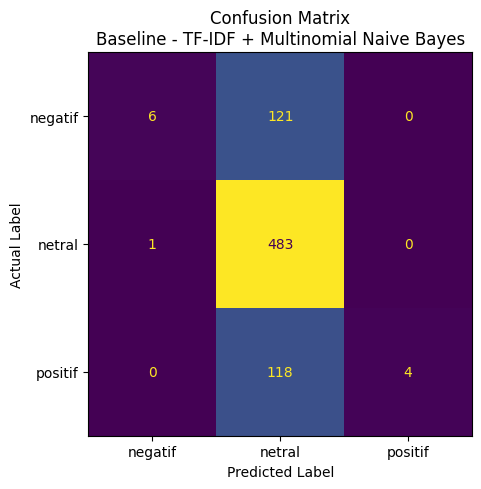

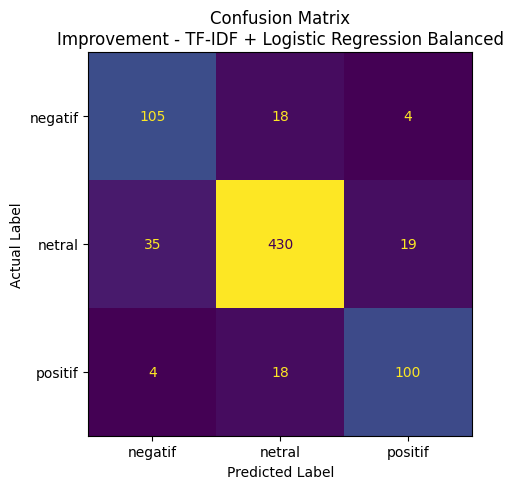

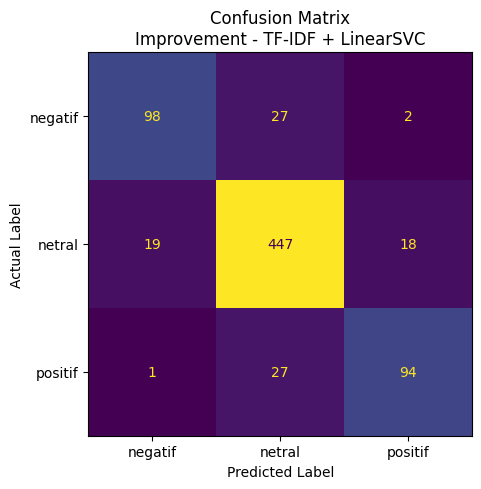

In [21]:
# ============================================================
# Visualisasi Confusion Matrix Semua Model
# ============================================================

for model_name, cm in confusion_matrices.items():
    fig, ax = plt.subplots(figsize=(6, 5))
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=EXPECTED_LABELS
    )
    
    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )
    
    ax.set_title(f"Confusion Matrix\n{model_name}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    
    plt.tight_layout()
    plt.show()

## 6. Interpretasi Awal Hasil Model Improvement

Berdasarkan hasil evaluasi awal, fokus utama analisis bukan hanya pada accuracy, tetapi juga pada metrik macro average, khususnya:

- `recall_macro`
- `f1_macro`

Hal ini penting karena dataset sentimen memiliki lebih dari satu kelas dan terdapat indikasi ketidakseimbangan distribusi label. Pada kasus seperti ini, accuracy saja dapat memberikan kesan performa yang terlalu optimistis apabila model terlalu sering memprediksi kelas mayoritas.

Model baseline Naive Bayes pada tahap sebelumnya cenderung dominan memprediksi kelas `netral`. Oleh karena itu, model improvement dinilai lebih baik apabila mampu:

1. Meningkatkan recall kelas `negatif`.
2. Meningkatkan recall kelas `positif`.
3. Mengurangi dominasi prediksi ke kelas `netral`.
4. Meningkatkan F1-score macro.
5. Tetap menjaga performa weighted average agar tidak turun terlalu jauh.

Pada tahap berikutnya, hasil evaluasi akan dianalisis lebih detail per kelas agar dapat diketahui model mana yang paling layak dipilih sebagai kandidat model final.

In [22]:
# ============================================================
# Analisis Performa Per Kelas
# ============================================================

per_class_rows = []

for model_name, report_dict in classification_reports_dict.items():
    for label in EXPECTED_LABELS:
        per_class_rows.append({
            "model": model_name,
            "label": label,
            "precision": report_dict[label]["precision"],
            "recall": report_dict[label]["recall"],
            "f1_score": report_dict[label]["f1-score"],
            "support": report_dict[label]["support"]
        })

df_per_class = pd.DataFrame(per_class_rows)

df_per_class_rounded = df_per_class.copy()
for col in ["precision", "recall", "f1_score"]:
    df_per_class_rounded[col] = df_per_class_rounded[col].round(4)

print("Performa model per kelas sentimen:")
display(df_per_class_rounded)

Performa model per kelas sentimen:


,model,label,precision,recall,f1_score,support
0,Baseline - TF-IDF + Multinomial Naive Bayes,negatif,0.8571,0.0472,0.0896,127.0
1,Baseline - TF-IDF + Multinomial Naive Bayes,netral,0.6690,0.9979,0.8010,484.0
2,Baseline - TF-IDF + Multinomial Naive Bayes,positif,1.0000,0.0328,0.0635,122.0
3,Improvement - TF-IDF + Logistic Regression Bal...,negatif,0.7292,0.8268,0.7749,127.0
4,Improvement - TF-IDF + Logistic Regression Bal...,netral,0.9227,0.8884,0.9053,484.0
5,Improvement - TF-IDF + Logistic Regression Bal...,positif,0.8130,0.8197,0.8163,122.0
6,Improvement - TF-IDF + LinearSVC,negatif,0.8305,0.7717,0.8000,127.0
7,Improvement - TF-IDF + LinearSVC,netral,0.8922,0.9236,0.9076,484.0
8,Improvement - TF-IDF + LinearSVC,positif,0.8246,0.7705,0.7966,122.0


In [23]:
# ============================================================
# Fokus Analisis Kelas Negatif dan Positif
# ============================================================

df_focus_minority = df_per_class[
    df_per_class["label"].isin(["negatif", "positif"])
].copy()

df_focus_minority_rounded = df_focus_minority.copy()
for col in ["precision", "recall", "f1_score"]:
    df_focus_minority_rounded[col] = df_focus_minority_rounded[col].round(4)

print("Fokus evaluasi pada kelas negatif dan positif:")
display(df_focus_minority_rounded)

Fokus evaluasi pada kelas negatif dan positif:


,model,label,precision,recall,f1_score,support
0,Baseline - TF-IDF + Multinomial Naive Bayes,negatif,0.8571,0.0472,0.0896,127.0
2,Baseline - TF-IDF + Multinomial Naive Bayes,positif,1.0000,0.0328,0.0635,122.0
3,Improvement - TF-IDF + Logistic Regression Bal...,negatif,0.7292,0.8268,0.7749,127.0
5,Improvement - TF-IDF + Logistic Regression Bal...,positif,0.8130,0.8197,0.8163,122.0
6,Improvement - TF-IDF + LinearSVC,negatif,0.8305,0.7717,0.8000,127.0
8,Improvement - TF-IDF + LinearSVC,positif,0.8246,0.7705,0.7966,122.0


## 7. Visualisasi Perbandingan Metrik dan Penyimpanan Laporan

Pada bagian ini, hasil evaluasi model akan divisualisasikan dan disimpan sebagai laporan agregat yang aman. Visualisasi yang dibuat tidak memuat komentar asli, identitas pengguna, maupun informasi sensitif.

Visualisasi yang akan dibuat meliputi:

1. Perbandingan metrik macro antar model.
2. Perbandingan accuracy dan F1-score weighted antar model.
3. Perbandingan recall dan F1-score untuk kelas `negatif` dan `positif`.
4. Confusion matrix setiap model.

Laporan yang disimpan ke folder `reports/` meliputi:

1. Ringkasan metrik evaluasi model.
2. Performa model per kelas.
3. Selisih performa model improvement terhadap baseline Naive Bayes.
4. Classification report dalam format teks dan JSON.
5. Interpretasi akademik model terbaik.

Catatan keamanan:

- Laporan tidak menyimpan komentar asli.
- Laporan tidak menyimpan API key.
- Laporan tidak menyimpan file `.env`.
- Laporan tidak menyimpan kolom `author`.
- Model artifact tidak disimpan pada tahap ini karena pipeline TF-IDF mengandung vocabulary dari teks.

In [24]:
# ============================================================
# Membuat Nama Model Ringkas dan Timestamp
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

def get_short_model_name(model_name):
    """
    Fungsi untuk membuat nama model lebih ringkas
    agar visualisasi lebih mudah dibaca.
    """
    if "Naive Bayes" in model_name:
        return "Naive Bayes"
    elif "Logistic Regression" in model_name:
        return "LogReg Balanced"
    elif "LinearSVC" in model_name:
        return "LinearSVC"
    else:
        return model_name


def slugify(text):
    """
    Fungsi untuk membuat nama file aman.
    """
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = text.strip("_")
    return text


# Menambahkan kolom nama model ringkas untuk kebutuhan visualisasi
df_evaluation_viz = df_evaluation.copy()
df_evaluation_viz["model_short"] = df_evaluation_viz["model"].apply(get_short_model_name)

df_per_class_viz = df_per_class.copy()
df_per_class_viz["model_short"] = df_per_class_viz["model"].apply(get_short_model_name)

print("Timestamp laporan:", timestamp)
print("Nama model ringkas:")
display(df_evaluation_viz[["model", "model_short"]])

Timestamp laporan: 20260530_233314
Nama model ringkas:


,model,model_short
0,Baseline - TF-IDF + Multinomial Naive Bayes,Naive Bayes
1,Improvement - TF-IDF + Logistic Regression Bal...,LogReg Balanced
2,Improvement - TF-IDF + LinearSVC,LinearSVC


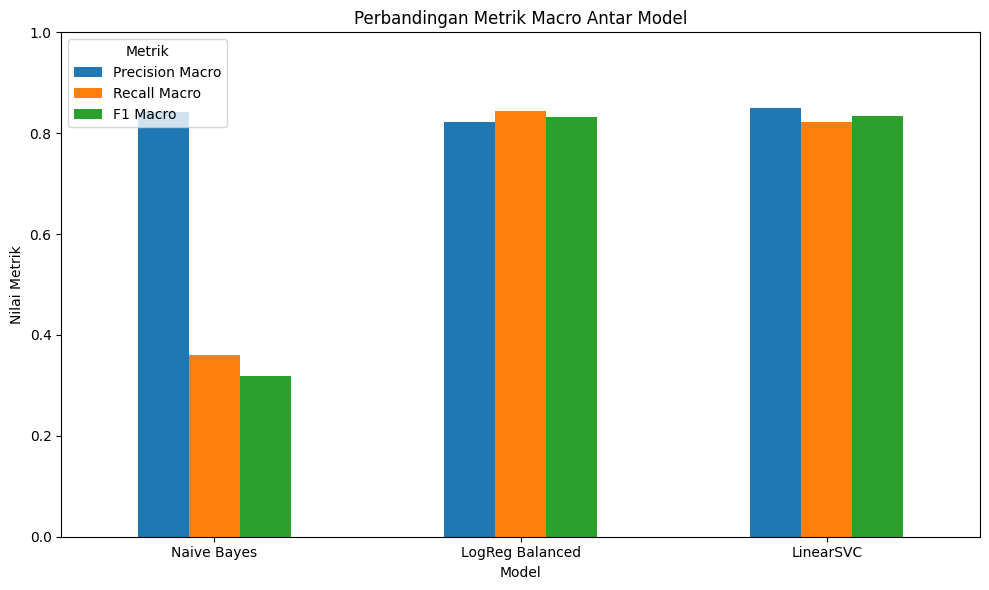

Visualisasi metrik macro berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\figures\model_improvement_macro_metrics_20260530_233314.png


In [25]:
# ============================================================
# Visualisasi Perbandingan Metrik Macro
# ============================================================

macro_metrics = [
    "precision_macro",
    "recall_macro",
    "f1_macro"
]

df_macro_plot = df_evaluation_viz.set_index("model_short")[macro_metrics]

ax = df_macro_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Perbandingan Metrik Macro Antar Model")
ax.set_xlabel("Model")
ax.set_ylabel("Nilai Metrik")
ax.set_ylim(0, 1)
ax.legend(
    title="Metrik",
    labels=["Precision Macro", "Recall Macro", "F1 Macro"]
)

plt.xticks(rotation=0)
plt.tight_layout()

macro_figure_path = FIGURES_DIR / f"model_improvement_macro_metrics_{timestamp}.png"
plt.savefig(macro_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Visualisasi metrik macro berhasil disimpan ke:")
print(macro_figure_path)

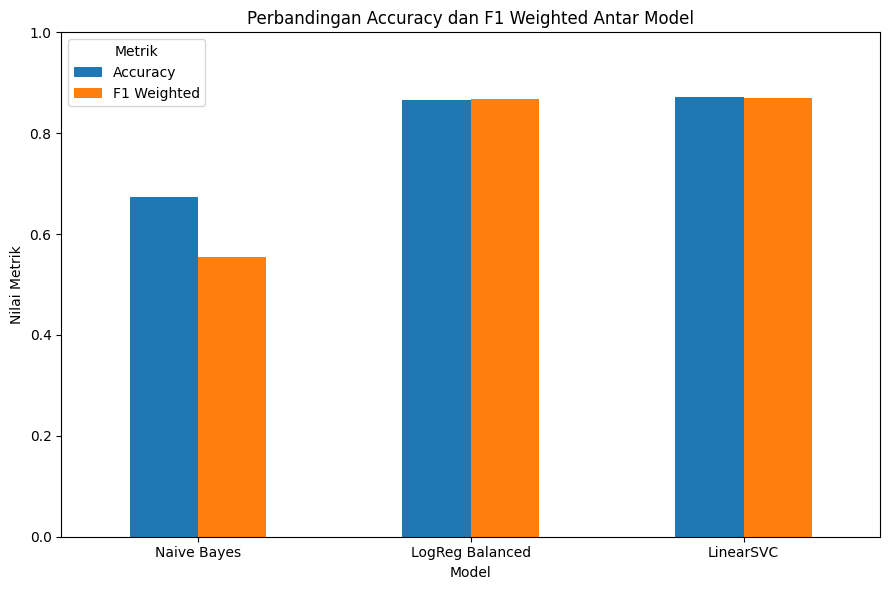

Visualisasi accuracy dan F1 weighted berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\figures\model_improvement_accuracy_f1_weighted_20260530_233314.png


In [26]:
# ============================================================
# Visualisasi Accuracy dan F1 Weighted
# ============================================================

weighted_metrics = [
    "accuracy",
    "f1_weighted"
]

df_weighted_plot = df_evaluation_viz.set_index("model_short")[weighted_metrics]

ax = df_weighted_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

ax.set_title("Perbandingan Accuracy dan F1 Weighted Antar Model")
ax.set_xlabel("Model")
ax.set_ylabel("Nilai Metrik")
ax.set_ylim(0, 1)
ax.legend(
    title="Metrik",
    labels=["Accuracy", "F1 Weighted"]
)

plt.xticks(rotation=0)
plt.tight_layout()

weighted_figure_path = FIGURES_DIR / f"model_improvement_accuracy_f1_weighted_{timestamp}.png"
plt.savefig(weighted_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Visualisasi accuracy dan F1 weighted berhasil disimpan ke:")
print(weighted_figure_path)

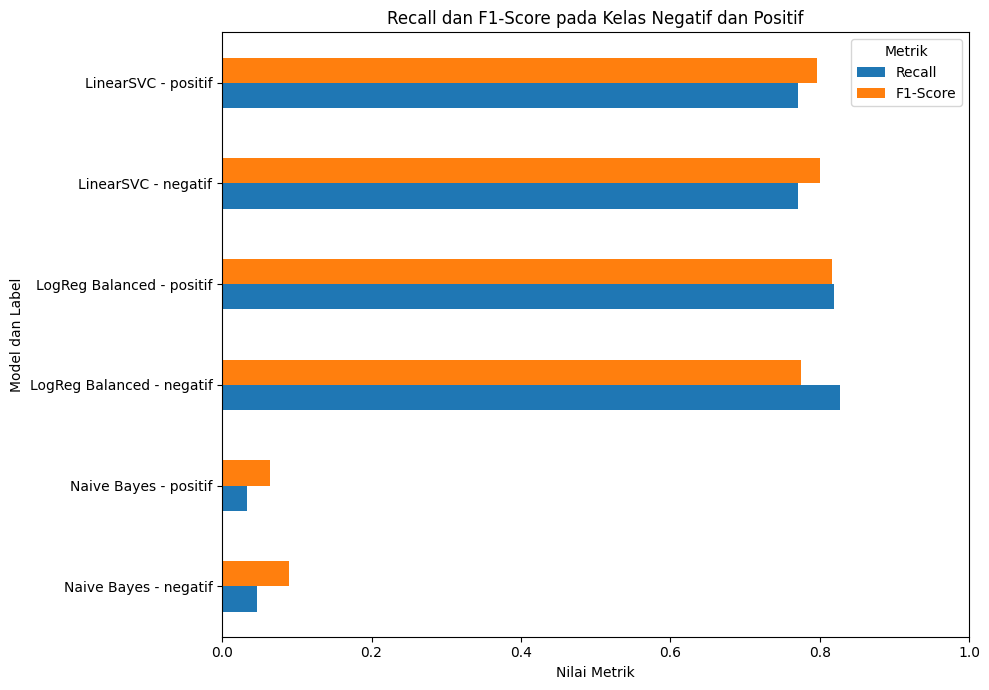

Visualisasi recall dan F1 kelas negatif-positif berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\figures\model_improvement_negative_positive_recall_f1_20260530_233314.png


In [27]:
# ============================================================
# Visualisasi Recall dan F1-Score Kelas Negatif dan Positif
# ============================================================

df_minority_plot = df_per_class_viz[
    df_per_class_viz["label"].isin(["negatif", "positif"])
].copy()

df_minority_plot["model_label"] = (
    df_minority_plot["model_short"] + " - " + df_minority_plot["label"]
)

df_minority_plot = df_minority_plot[
    ["model_label", "recall", "f1_score"]
].set_index("model_label")

ax = df_minority_plot.plot(
    kind="barh",
    figsize=(10, 7)
)

ax.set_title("Recall dan F1-Score pada Kelas Negatif dan Positif")
ax.set_xlabel("Nilai Metrik")
ax.set_ylabel("Model dan Label")
ax.set_xlim(0, 1)
ax.legend(
    title="Metrik",
    labels=["Recall", "F1-Score"]
)

plt.tight_layout()

minority_figure_path = FIGURES_DIR / f"model_improvement_negative_positive_recall_f1_{timestamp}.png"
plt.savefig(minority_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Visualisasi recall dan F1 kelas negatif-positif berhasil disimpan ke:")
print(minority_figure_path)

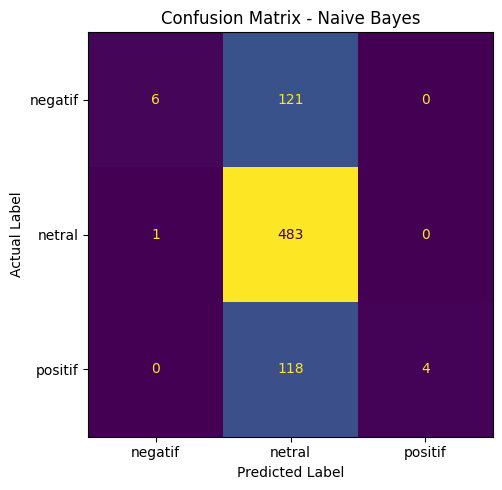

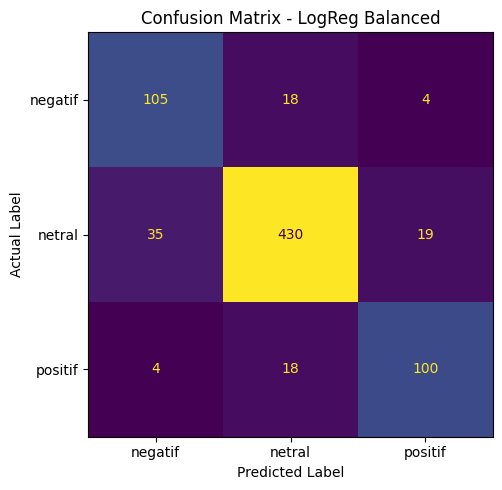

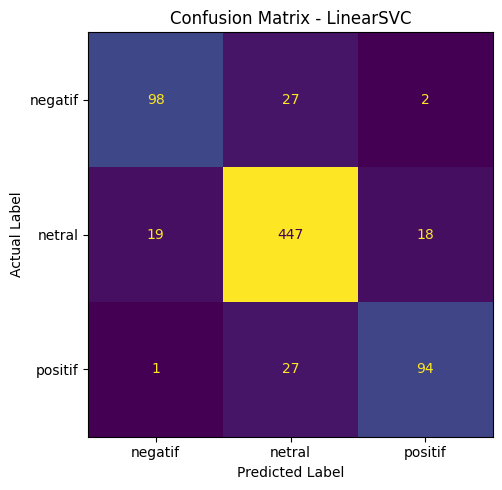

Seluruh confusion matrix berhasil disimpan:
- Naive Bayes: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\figures\confusion_matrix_naive_bayes_20260530_233314.png
- LogReg Balanced: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\figures\confusion_matrix_logreg_balanced_20260530_233314.png
- LinearSVC: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\figures\confusion_matrix_linearsvc_20260530_233314.png


In [28]:
# ============================================================
# Menyimpan Confusion Matrix Setiap Model
# ============================================================

confusion_matrix_paths = {}

for model_name, cm in confusion_matrices.items():
    short_name = get_short_model_name(model_name)
    safe_name = slugify(short_name)

    fig, ax = plt.subplots(figsize=(6, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=EXPECTED_LABELS
    )

    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )

    ax.set_title(f"Confusion Matrix - {short_name}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

    plt.tight_layout()

    cm_path = FIGURES_DIR / f"confusion_matrix_{safe_name}_{timestamp}.png"
    plt.savefig(cm_path, dpi=300, bbox_inches="tight")
    plt.show()

    confusion_matrix_paths[model_name] = str(cm_path)

print("Seluruh confusion matrix berhasil disimpan:")
for model_name, path in confusion_matrix_paths.items():
    print(f"- {get_short_model_name(model_name)}: {path}")

## 8. Analisis Selisih Performa terhadap Baseline

Setelah seluruh model dievaluasi, tahap berikutnya adalah menghitung selisih performa model improvement terhadap baseline Naive Bayes.

Baseline digunakan sebagai titik pembanding karena model tersebut merupakan model awal yang telah dibuat pada tahap sebelumnya. Model improvement dianggap lebih baik apabila mampu meningkatkan metrik macro, khususnya:

- `recall_macro`
- `f1_macro`

Selain itu, analisis juga difokuskan pada peningkatan recall dan F1-score untuk kelas `negatif` dan `positif`, karena dua kelas tersebut sebelumnya sulit dikenali oleh model baseline.

In [29]:
# ============================================================
# Menghitung Selisih Metrik terhadap Baseline
# ============================================================

baseline_model_name = "Baseline - TF-IDF + Multinomial Naive Bayes"

if baseline_model_name not in df_evaluation["model"].values:
    raise ValueError(
        "Baseline Naive Bayes tidak ditemukan pada df_evaluation. "
        "Pastikan nama model baseline sesuai dengan pipeline yang dibuat."
    )

baseline_metrics = df_evaluation[
    df_evaluation["model"] == baseline_model_name
].iloc[0]

delta_rows = []

for _, row in df_evaluation.iterrows():
    delta_row = {
        "model": row["model"],
        "model_short": get_short_model_name(row["model"])
    }

    for metric in [
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted"
    ]:
        delta_row[f"delta_{metric}"] = row[metric] - baseline_metrics[metric]

    delta_rows.append(delta_row)

df_delta_vs_baseline = pd.DataFrame(delta_rows)

df_delta_vs_baseline_rounded = df_delta_vs_baseline.copy()
delta_numeric_cols = df_delta_vs_baseline_rounded.select_dtypes(include=[np.number]).columns
df_delta_vs_baseline_rounded[delta_numeric_cols] = (
    df_delta_vs_baseline_rounded[delta_numeric_cols].round(4)
)

print("Selisih performa model terhadap baseline Naive Bayes:")
display(df_delta_vs_baseline_rounded)

Selisih performa model terhadap baseline Naive Bayes:


,model,model_short,delta_accuracy,delta_precision_macro,delta_recall_macro,delta_f1_macro,delta_precision_weighted,delta_recall_weighted,delta_f1_weighted
0,Baseline - TF-IDF + Multinomial Naive Bayes,Naive Bayes,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,Improvement - TF-IDF + Logistic Regression Bal...,LogReg Balanced,0.1937,-0.0204,0.4856,0.5142,0.1143,0.1937,0.3129
2,Improvement - TF-IDF + LinearSVC,LinearSVC,0.1992,0.0071,0.4626,0.5167,0.1136,0.1992,0.3155


In [30]:
# ============================================================
# Menentukan Model Terbaik dengan Prioritas F1 Macro dan Recall Macro
# ============================================================

df_model_selection = df_evaluation.copy()

# Model terbaik dipilih berdasarkan F1 Macro terlebih dahulu,
# kemudian Recall Macro sebagai kriteria tambahan.
df_model_selection = df_model_selection.sort_values(
    by=["f1_macro", "recall_macro", "f1_weighted"],
    ascending=False
)

best_model_info = df_model_selection.iloc[0]

best_model_name = best_model_info["model"]
best_model_short = get_short_model_name(best_model_name)

print("Model terbaik berdasarkan prioritas F1 Macro, Recall Macro, dan F1 Weighted:")
print(f"Model             : {best_model_name}")
print(f"Nama ringkas      : {best_model_short}")
print(f"Accuracy          : {best_model_info['accuracy']:.4f}")
print(f"Precision Macro   : {best_model_info['precision_macro']:.4f}")
print(f"Recall Macro      : {best_model_info['recall_macro']:.4f}")
print(f"F1 Macro          : {best_model_info['f1_macro']:.4f}")
print(f"F1 Weighted       : {best_model_info['f1_weighted']:.4f}")

Model terbaik berdasarkan prioritas F1 Macro, Recall Macro, dan F1 Weighted:
Model             : Improvement - TF-IDF + LinearSVC
Nama ringkas      : LinearSVC
Accuracy          : 0.8718
Precision Macro   : 0.8491
Recall Macro      : 0.8219
F1 Macro          : 0.8347
F1 Weighted       : 0.8705


In [31]:
# ============================================================
# Analisis Performa Model Terbaik per Kelas
# ============================================================

df_best_per_class = df_per_class[
    df_per_class["model"] == best_model_name
].copy()

df_best_per_class_display = df_best_per_class.copy()

for col in ["precision", "recall", "f1_score"]:
    df_best_per_class_display[col] = df_best_per_class_display[col].round(4)

print(f"Performa per kelas untuk model terbaik: {best_model_short}")
display(df_best_per_class_display[[
    "label",
    "precision",
    "recall",
    "f1_score",
    "support"
]])

Performa per kelas untuk model terbaik: LinearSVC


,label,precision,recall,f1_score,support
6,negatif,0.8305,0.7717,0.8000,127.0
7,netral,0.8922,0.9236,0.9076,484.0
8,positif,0.8246,0.7705,0.7966,122.0


In [32]:
# ============================================================
# Membuat Interpretasi Akademik Otomatis
# ============================================================

baseline_row = df_evaluation[
    df_evaluation["model"] == baseline_model_name
].iloc[0]

best_row = df_evaluation[
    df_evaluation["model"] == best_model_name
].iloc[0]

delta_f1_macro = best_row["f1_macro"] - baseline_row["f1_macro"]
delta_recall_macro = best_row["recall_macro"] - baseline_row["recall_macro"]
delta_accuracy = best_row["accuracy"] - baseline_row["accuracy"]

# Ambil performa kelas negatif dan positif pada baseline dan model terbaik
def get_class_metric(df_class, model_name, label, metric):
    value = df_class[
        (df_class["model"] == model_name) &
        (df_class["label"] == label)
    ][metric].iloc[0]
    return value


baseline_neg_recall = get_class_metric(df_per_class, baseline_model_name, "negatif", "recall")
baseline_pos_recall = get_class_metric(df_per_class, baseline_model_name, "positif", "recall")
best_neg_recall = get_class_metric(df_per_class, best_model_name, "negatif", "recall")
best_pos_recall = get_class_metric(df_per_class, best_model_name, "positif", "recall")

baseline_neg_f1 = get_class_metric(df_per_class, baseline_model_name, "negatif", "f1_score")
baseline_pos_f1 = get_class_metric(df_per_class, baseline_model_name, "positif", "f1_score")
best_neg_f1 = get_class_metric(df_per_class, best_model_name, "negatif", "f1_score")
best_pos_f1 = get_class_metric(df_per_class, best_model_name, "positif", "f1_score")

interpretation_text = f"""
INTERPRETASI AKADEMIK MODEL IMPROVEMENT SENTIMENT CLASSIFICATION
================================================================

Tahap model improvement dilakukan untuk memperbaiki kelemahan model baseline
TF-IDF + Multinomial Naive Bayes yang sebelumnya cenderung dominan memprediksi
kelas netral. Pada konteks klasifikasi sentimen tiga kelas, evaluasi tidak cukup
hanya menggunakan accuracy, karena accuracy dapat terlihat cukup baik walaupun
model gagal mengenali kelas minoritas seperti negatif dan positif.

Berdasarkan hasil evaluasi, model terbaik pada tahap ini adalah:

{best_model_name}

Ringkasan performa model terbaik:
- Accuracy        : {best_row['accuracy']:.4f}
- Precision Macro : {best_row['precision_macro']:.4f}
- Recall Macro    : {best_row['recall_macro']:.4f}
- F1-Score Macro  : {best_row['f1_macro']:.4f}
- F1-Score Weighted: {best_row['f1_weighted']:.4f}

Dibandingkan baseline Naive Bayes:
- Perubahan Accuracy     : {delta_accuracy:+.4f}
- Perubahan Recall Macro : {delta_recall_macro:+.4f}
- Perubahan F1 Macro     : {delta_f1_macro:+.4f}

Fokus evaluasi pada kelas negatif dan positif:
1. Kelas negatif
   - Recall baseline      : {baseline_neg_recall:.4f}
   - Recall model terbaik : {best_neg_recall:.4f}
   - F1 baseline          : {baseline_neg_f1:.4f}
   - F1 model terbaik     : {best_neg_f1:.4f}

2. Kelas positif
   - Recall baseline      : {baseline_pos_recall:.4f}
   - Recall model terbaik : {best_pos_recall:.4f}
   - F1 baseline          : {baseline_pos_f1:.4f}
   - F1 model terbaik     : {best_pos_f1:.4f}

Secara akademik, model improvement dapat dinilai lebih representatif apabila
terjadi peningkatan pada recall dan F1-score macro. Recall macro menunjukkan
kemampuan model dalam mengenali seluruh kelas secara lebih seimbang, sedangkan
F1-score macro menunjukkan keseimbangan antara precision dan recall tanpa
terlalu dipengaruhi oleh dominasi kelas mayoritas.

Apabila model terbaik memiliki F1 macro dan recall macro yang lebih tinggi
dibandingkan baseline, maka model tersebut lebih layak dipilih sebagai kandidat
model final. Namun, apabila accuracy sedikit menurun tetapi recall kelas negatif
dan positif meningkat, kondisi tersebut masih dapat diterima karena tujuan utama
tahap ini adalah mengurangi bias prediksi terhadap kelas netral dan meningkatkan
kemampuan model mengenali sentimen non-netral.

Dengan demikian, model terbaik pada tahap ini dapat dijadikan kandidat utama
untuk tahap finalisasi model, sebelum dilanjutkan ke tahap penyusunan dashboard
atau deployment menggunakan Streamlit.
"""

print(interpretation_text)


INTERPRETASI AKADEMIK MODEL IMPROVEMENT SENTIMENT CLASSIFICATION

Tahap model improvement dilakukan untuk memperbaiki kelemahan model baseline
TF-IDF + Multinomial Naive Bayes yang sebelumnya cenderung dominan memprediksi
kelas netral. Pada konteks klasifikasi sentimen tiga kelas, evaluasi tidak cukup
hanya menggunakan accuracy, karena accuracy dapat terlihat cukup baik walaupun
model gagal mengenali kelas minoritas seperti negatif dan positif.

Berdasarkan hasil evaluasi, model terbaik pada tahap ini adalah:

Improvement - TF-IDF + LinearSVC

Ringkasan performa model terbaik:
- Accuracy        : 0.8718
- Precision Macro : 0.8491
- Recall Macro    : 0.8219
- F1-Score Macro  : 0.8347
- F1-Score Weighted: 0.8705

Dibandingkan baseline Naive Bayes:
- Perubahan Accuracy     : +0.1992
- Perubahan Recall Macro : +0.4626
- Perubahan F1 Macro     : +0.5167

Fokus evaluasi pada kelas negatif dan positif:
1. Kelas negatif
   - Recall baseline      : 0.0472
   - Recall model terbaik : 0.7717
   

In [33]:
# ============================================================
# Menyimpan Laporan Evaluasi ke Folder Reports
# ============================================================

# Path file laporan
evaluation_summary_path = REPORTS_DIR / f"model_improvement_evaluation_summary_{timestamp}.csv"
per_class_metrics_path = REPORTS_DIR / f"model_improvement_per_class_metrics_{timestamp}.csv"
delta_metrics_path = REPORTS_DIR / f"model_improvement_delta_vs_baseline_{timestamp}.csv"
classification_report_json_path = REPORTS_DIR / f"model_improvement_classification_reports_{timestamp}.json"
classification_report_txt_path = REPORTS_DIR / f"model_improvement_classification_reports_{timestamp}.txt"
interpretation_path = REPORTS_DIR / f"model_improvement_academic_interpretation_{timestamp}.txt"

# Simpan ringkasan metrik
df_evaluation_rounded.to_csv(
    evaluation_summary_path,
    index=False,
    encoding="utf-8-sig"
)

# Simpan metrik per kelas
df_per_class_rounded.to_csv(
    per_class_metrics_path,
    index=False,
    encoding="utf-8-sig"
)

# Simpan delta terhadap baseline
df_delta_vs_baseline_rounded.to_csv(
    delta_metrics_path,
    index=False,
    encoding="utf-8-sig"
)

# Simpan classification report dalam JSON
with open(classification_report_json_path, "w", encoding="utf-8") as f:
    json.dump(classification_reports_dict, f, indent=4, ensure_ascii=False)

# Simpan classification report dalam TXT
with open(classification_report_txt_path, "w", encoding="utf-8") as f:
    for model_name, report_text in classification_reports_text.items():
        f.write("=" * 100 + "\n")
        f.write(f"{model_name}\n")
        f.write("=" * 100 + "\n")
        f.write(report_text)
        f.write("\n\n")

# Simpan interpretasi akademik
with open(interpretation_path, "w", encoding="utf-8") as f:
    f.write(interpretation_text)

print("Laporan evaluasi model improvement berhasil disimpan.")
print("\nDaftar file laporan:")
print(f"1. {evaluation_summary_path}")
print(f"2. {per_class_metrics_path}")
print(f"3. {delta_metrics_path}")
print(f"4. {classification_report_json_path}")
print(f"5. {classification_report_txt_path}")
print(f"6. {interpretation_path}")

print("\nDaftar file visualisasi:")
print(f"1. {macro_figure_path}")
print(f"2. {weighted_figure_path}")
print(f"3. {minority_figure_path}")

for idx, path in enumerate(confusion_matrix_paths.values(), start=4):
    print(f"{idx}. {path}")

Laporan evaluasi model improvement berhasil disimpan.

Daftar file laporan:
1. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\model_improvement_evaluation_summary_20260530_233314.csv
2. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\model_improvement_per_class_metrics_20260530_233314.csv
3. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\model_improvement_delta_vs_baseline_20260530_233314.csv
4. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\model_improvement_classification_reports_20260530_233314.json
5. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\model_improvement_classification_reports_20260530_233314.txt
6. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\model_improvement_academic_interpretation_20260530_233314.txt

Daftar file visualisasi:
1. D:\DATA

## 9. Interpretasi Akademik Model Terbaik

Model terbaik pada tahap ini dipilih berdasarkan prioritas utama pada `F1-Score Macro`, kemudian `Recall Macro`, dan terakhir `F1-Score Weighted`.

Pemilihan `F1-Score Macro` sebagai metrik utama dilakukan karena dataset sentimen memiliki tiga kelas, yaitu `negatif`, `netral`, dan `positif`. Dalam kasus seperti ini, model tidak boleh hanya dinilai dari accuracy, karena accuracy dapat menjadi bias apabila sebagian besar data berada pada satu kelas dominan.

Model improvement dianggap berhasil apabila mampu:

1. Meningkatkan kemampuan deteksi kelas `negatif`.
2. Meningkatkan kemampuan deteksi kelas `positif`.
3. Mengurangi dominasi prediksi terhadap kelas `netral`.
4. Meningkatkan nilai `recall_macro`.
5. Meningkatkan nilai `f1_macro`.

Apabila model terbaik mengalami sedikit penurunan accuracy tetapi mampu meningkatkan recall dan F1-score pada kelas `negatif` dan `positif`, maka model tersebut tetap dapat dianggap lebih baik secara analitis. Hal ini karena tujuan utama klasifikasi sentimen bukan hanya memperoleh prediksi mayoritas yang benar, tetapi juga mengenali variasi sentimen secara lebih seimbang.

Dengan demikian, model terbaik pada tahap ini dapat digunakan sebagai kandidat model final sebelum dilakukan tahap lanjutan, seperti tuning parameter sederhana, finalisasi model, interpretasi error, dan persiapan deployment.